In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.special import expit
import pymc as pm
import arviz as az

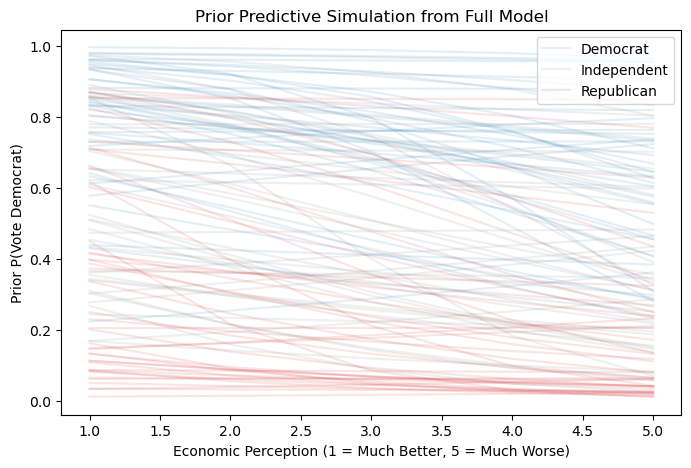

,party_id,econ_perception,mean_prior_p,mean_simulated_vote
0,Democrat,1,0.809881,0.92
1,Democrat,2,0.776392,0.78
2,Democrat,3,0.732580,0.72
3,Democrat,4,0.678346,0.74
4,Democrat,5,0.618492,0.56
5,Independent,1,0.573285,0.66
6,Independent,2,0.519290,0.50
7,Independent,3,0.462188,0.48
8,Independent,4,0.406742,0.42
9,Independent,5,0.357227,0.34


In [2]:


# ----------------------------
# Prior predictive simulation
# ----------------------------

np.random.seed(42)

n_samples = 50
econ = np.arange(1, 6)
econ_centered = econ - 3

party_labels = ["Democrat", "Independent", "Republican"]

# Priors for model parameters
alpha_samples = np.random.normal(loc=0, scale=1, size=n_samples)

# Prior belief: worse economy should usually reduce Democratic incumbent vote
beta_econ_samples = np.random.normal(loc=-0.3, scale=0.3, size=n_samples)

# Party ID prior effects on logit scale
party_effect_samples = {
    "Democrat": np.random.normal(loc=1.5, scale=0.7, size=n_samples),
    "Independent": np.random.normal(loc=0.0, scale=0.5, size=n_samples),
    "Republican": np.random.normal(loc=-1.5, scale=0.7, size=n_samples),
}

# Store simulated results
sim_rows = []

for i in range(n_samples):
    for party in party_labels:
        for e, ec in zip(econ, econ_centered):
            logit_p = (
                alpha_samples[i]
                + beta_econ_samples[i] * ec
                + party_effect_samples[party][i]
            )
            p = expit(logit_p)

            # Simulated vote outcome from Bernoulli model
            y_sim = np.random.binomial(n=1, p=p)

            sim_rows.append({
                "simulation": i,
                "econ_perception": e,
                "party_id": party,
                "p_vote_dem": p,
                "simulated_vote_dem": y_sim
            })

prior_sim_df = pd.DataFrame(sim_rows)

# ----------------------------
# Plot simulated probabilities
# ----------------------------

fig, ax = plt.subplots(figsize=(8, 5))

# Define colors
party_colors = {
    "Democrat": "#1f77b4",     # blue
    "Republican": "#d62728",   # red
    "Independent": "#7f7f7f"   # gray
}

for party in party_labels:
    party_df = prior_sim_df[prior_sim_df["party_id"] == party]

    for sim_id in party_df["simulation"].unique()[:40]:
        temp = party_df[party_df["simulation"] == sim_id]
        ax.plot(
            temp["econ_perception"],
            temp["p_vote_dem"],
            color=party_colors[party],
            alpha=0.12,
            label=party if sim_id == 0 else None
        )

ax.set_xlabel("Economic Perception (1 = Much Better, 5 = Much Worse)")
ax.set_ylabel("Prior P(Vote Democrat)")
ax.set_title("Prior Predictive Simulation from Full Model")

# Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

prior_full_model_plot = ax
plt.show()

# ----------------------------
# Summarize simulated outcomes
# ----------------------------

summary = (
    prior_sim_df
    .groupby(["party_id", "econ_perception"])
    .agg(
        mean_prior_p=("p_vote_dem", "mean"),
        mean_simulated_vote=("simulated_vote_dem", "mean")
    )
    .reset_index()
)

summary

In [7]:
# Load processed data
df = pd.read_csv("../data/processed/cleaned_data.csv")

# Explicit party coding
# Independent = baseline
party_map = {
    "Independent": 0,
    "Democrat": 1,
    "Republican": 2
}

df["party_code"] = df["party_id"].map(party_map)

# Prepare variables
econ_centered = df["econ_perception"].to_numpy(dtype="float64") - 3
party = df["party_code"].to_numpy(dtype="int64")
y = df["voted_dem_house"].to_numpy(dtype="int64")

# Model
with pm.Model() as vote_model:
    
    # Priors
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta_econ = pm.Normal("beta_econ", mu=-0.3, sigma=0.3)

    # Party effects with Independent as baseline
    gamma_raw = pm.Normal("gamma_raw", mu=0, sigma=1.5, shape=2)
    gamma_party = pm.math.concatenate([[0], gamma_raw])

    # Linear predictor
    logit_p = alpha + beta_econ * econ_centered + gamma_party[party]

    # Likelihood
    vote = pm.Bernoulli(
        "vote",
        logit_p=logit_p,
        observed=y
    )

    # MCMC sampling
    idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

# Summary
az.summary(idata, var_names=["alpha", "beta_econ", "gamma_raw"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_econ, gamma_raw]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 21 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.248,0.035,1.184,1.314,0.001,0.001,1643.0,2189.0,1.0
beta_econ,-1.031,0.020,-1.069,-0.996,0.000,0.000,2016.0,2232.0,1.0
gamma_raw[0],2.658,0.045,2.572,2.740,0.001,0.001,2589.0,2579.0,1.0
gamma_raw[1],-2.766,0.053,-2.863,-2.669,0.001,0.001,2512.0,2987.0,1.0
